# 无监督学习
## 序
无监督学习是机器学习的一个重要分支，它与监督学习不同，不依赖于标注数据。无监督学习的目标是从未标注的数据中发现隐藏的模式、结构或关系。这种学习方法在许多领域都有广泛的应用，如聚类、降维、异常检测等。
聚类是无监督学习中最常见的任务之一。它的目标是将数据点分组，使得同一组内的数据点相似度较高，而不同组之间的数据点相似度较低。常见的聚类算法包括K-means、层次聚类和DBSCAN等。这里将着重介绍K-means算法，它是一种基于距离的聚类方法，通过迭代优化来找到最佳的聚类中心。
降维是无监督学习的另一个重要任务，旨在将高维数据映射到低维空间，同时尽可能保留数据的结构和信息。常见的降维方法包括主成分分析（PCA）和t-SNE等。这些方法可以帮助我们更好地理解数据的结构，进行可视化，并提高后续任务的效率。

## 聚类
### K-Means 聚类算法
聚类算法非常适用于低维数据集，以下是它的迭代步骤：
1. **初始化**：随机选择 $k$ 个数据点作为“质心”
2. **分配**：将每个数据点分配给最近的质心，形成 $k$ 个簇
3. **更新**：重新计算每个簇的质心
4. **重复**：重复步骤 2 和 3，直到质心不再发生变化或达到预设的迭代次数

K-Means 的目标函数是最小化簇内的平方误差，定义如下：
$$J = \sum_{i=1}^{k} \sum_{\mathbf{x} \in S_i} \|\mathbf{x} - \boldsymbol{\mu}_i\|^2$$
其中 $S_i$ 是第 $i$ 个簇，$\boldsymbol{\mu}_i$ 是第 $i$ 个簇的质心。

### 实践
一个非常经典的例子是手写数字，这里使用load_digits数据集。它是scikit-learn库中提供的一个包含1797个8x8像素的手写数字图像的数据集。每个图像被展平为一个64维的特征向量，代表每个像素的灰度值。我们可以使用K-Means算法对这些数据进行聚类，以发现数据中的自然分组。

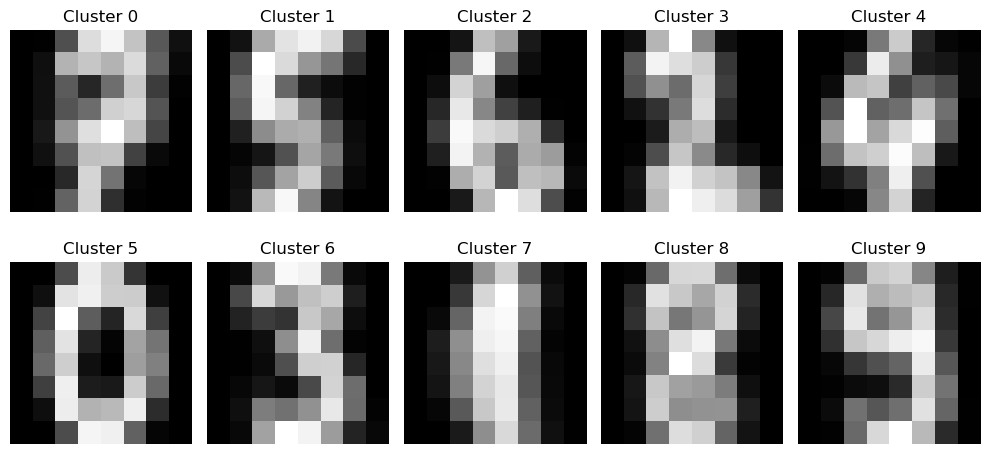

In [8]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.cluster import KMeans

# 加载数据
digits = load_digits()
X = digits.data
# 使用K-Means进行聚类
kmeans = KMeans(n_clusters=10, random_state=42)
y_kmeans = kmeans.fit_predict(X)
# 可视化聚类结果，展示其对应的手写数字图像
centers = kmeans.cluster_centers_.reshape(-1, 8, 8)
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for i in range(10):
    ax = axes[i // 5, i % 5]
    ax.imshow(centers[i], cmap='gray')
    ax.set_title(f'Cluster {i}')
    ax.axis('off')
plt.tight_layout()
plt.show()


可以看到，不加任何处理，K-Means算法就自动将相似的数字聚集，各簇质心直接呈现为各个数字的平均图像。接下来我们直接肉眼识别标签，再计算正确率。

In [9]:
import numpy as np
from collections import Counter

# 肉眼映射：cluster 0-9 -> digit 7,5,6,2,4,0,3,1,8,9
mapping_str = "7562403189"
cluster_to_digit = {i: int(ch) for i, ch in enumerate(mapping_str)}

y_true = digits.target
y_cluster = y_kmeans
y_pred = np.array([cluster_to_digit[c] for c in y_cluster])

# 总体正确率
overall_acc = (y_pred == y_true).mean()
print(f"总体正确率: {overall_acc:.4f}")

# 各数字正确率
print("\n各数字正确率:")
for d in range(10):
    idx = (y_true == d)
    correct = (y_pred[idx] == d).sum()
    total = idx.sum()
    acc = correct / total if total > 0 else 0.0
    print(f"数字 {d}: {acc:.4f}  ({correct}/{total})")

总体正确率: 0.8614

各数字正确率:
数字 0: 0.9888  (176/178)
数字 1: 0.7143  (130/182)
数字 2: 0.8249  (146/177)
数字 3: 0.8689  (159/183)
数字 4: 0.8785  (159/181)
数字 5: 0.7527  (137/182)
数字 6: 0.9724  (176/181)
数字 7: 0.9441  (169/179)
数字 8: 0.7816  (136/174)
数字 9: 0.8889  (160/180)


其中数字1，5，8的正确率较低，这甚至在质心图像中也能看出，这些数字的平均图像较为模糊，它们与其他数字的相似度较高，导致K-Means算法难以正确区分它们。

## 降维
### 一、 主成分分析 (Principal Component Analysis, PCA)

**1. 算法定义与目标**
PCA 是一种线性的正交线性变换算法。其目标是将高维数据映射到一个低维线性空间，使得投影后的数据方差最大化（即保留最多的原始信息），或等价地，使得原数据点与投影点之间的均方重构误差最小化。

**2. 输入与预处理**
设数据集为 $X = [\mathbf{x}_1, \mathbf{x}_2, \dots, \mathbf{x}_n]^T \in \mathbb{R}^{n \times d}$，其中 $n$ 为样本数，$d$ 为特征维度。
必须先对数据进行中心化处理（Mean Centering）：
$$\mu = \frac{1}{n} \sum_{i=1}^{n} \mathbf{x}_i$$
$$\tilde{X} = X - \mathbf{1}\mu^T$$
此时，$\tilde{X}$ 的每一列均值为 0。

**3. 计算协方差矩阵 (Covariance Matrix)**
定义样本的无偏协方差矩阵 $C \in \mathbb{R}^{d \times d}$：
$$C = \frac{1}{n-1} \tilde{X}^T \tilde{X}$$

**4. 求解特征值分解 (Eigen Decomposition)**
对协方差矩阵 $C$ 进行特征值分解：
$$C \mathbf{v}_k = \lambda_k \mathbf{v}_k$$
求解得到 $d$ 个非负特征值 $\lambda_1 \ge \lambda_2 \ge \dots \ge \lambda_d \ge 0$ 以及对应的正交单位特征向量 $\mathbf{v}_1, \mathbf{v}_2, \dots, \mathbf{v}_d$。
* $\lambda_k$ 表示第 $k$ 个主成分所能解释的方差大小。
* $\mathbf{v}_k$ 即为第 $k$ 个主成分的方向。

**5. 降维投影 (Dimensionality Reduction)**
若需将数据降至 $k$ 维 ($k < d$)，选取前 $k$ 个最大特征值对应的特征向量组成投影矩阵 $W = [\mathbf{v}_1, \mathbf{v}_2, \dots, \mathbf{v}_k] \in \mathbb{R}^{d \times k}$。
最终的降维数据矩阵 $Y \in \mathbb{R}^{n \times k}$ 计算如下：
$$Y = \tilde{X} W$$

### 二、 t-分布随机邻域嵌入 (t-Distributed Stochastic Neighbor Embedding, t-SNE)

**1. 算法定义与目标**
t-SNE 是一种非线性降维与流形学习算法，主要用于高维数据的二维或三维可视化。其目标是通过最小化高维空间与低维空间中概率分布的 Kullback-Leibler (KL) 散度，尽可能保留数据的局部邻域结构，同时通过长尾分布缓解“拥挤问题 (Crowding Problem)”。

**2. 构建高维空间的联合概率分布 $P$ (基于高斯分布)**
设高维数据集为 $X = \{\mathbf{x}_1, \mathbf{x}_2, \dots, \mathbf{x}_n\} \subset \mathbb{R}^d$。
首先计算给定 $\mathbf{x}_i$ 时 $\mathbf{x}_j$ 为其邻居的条件概率（使用高斯分布）：
$$p_{j|i} = \frac{\exp(-\|\mathbf{x}_i - \mathbf{x}_j\|^2 / 2\sigma_i^2)}{\sum_{k \neq i} \exp(-\|\mathbf{x}_i - \mathbf{x}_k\|^2 / 2\sigma_i^2)}$$
其中，方差 $\sigma_i^2$ 针对每个样本 $\mathbf{x}_i$ 单独计算。由用户指定的超参数 **困惑度 (Perplexity)** 决定，满足香农熵等式：
$$Perplexity = 2^{H(P_i)}$$
$$H(P_i) = - \sum_{j \neq i} p_{j|i} \log_2 p_{j|i}$$
为简化梯度并对称化分布，定义高维空间的联合概率 $p_{ij}$（设定 $p_{ii} = 0$）：
$$p_{ij} = \frac{p_{j|i} + p_{i|j}}{2n}$$

**3. 构建低维空间的联合概率分布 $Q$ (基于 Student t-分布)**
设低维映射后的数据集为 $Y = \{\mathbf{y}_1, \mathbf{y}_2, \dots, \mathbf{y}_n\} \subset \mathbb{R}^k$ (通常 $k=2,3$)。
为解决维度诅咒带来的拥挤问题，低维空间采用自由度为 1 的 Student t-分布（即柯西分布，具有重尾特性）计算联合概率（设定 $q_{ii} = 0$）：
$$q_{ij} = \frac{(1 + \|\mathbf{y}_i - \mathbf{y}_j\|^2)^{-1}}{\sum_{k \neq l} (1 + \|\mathbf{y}_k - \mathbf{y}_l\|^2)^{-1}}$$

**4. 目标函数 (损失函数)**
定义目标函数 $C$ 为概率分布 $P$ 和 $Q$ 之间的 KL 散度：
$$C = KL(P || Q) = \sum_{i \neq j} p_{ij} \log \frac{p_{ij}}{q_{ij}}$$

**5. 梯度下降与坐标更新 (Gradient Descent)**
目标函数 $C$ 对低维坐标 $\mathbf{y}_i$ 的解析梯度为：
$$\frac{\partial C}{\partial \mathbf{y}_i} = 4 \sum_{j} (p_{ij} - q_{ij}) (1 + \|\mathbf{y}_i - \mathbf{y}_j\|^2)^{-1} (\mathbf{y}_i - \mathbf{y}_j)$$
利用该梯度，通过带有动量 (Momentum) 和早期夸大 (Early Exaggeration) 技巧的梯度下降法迭代更新 $\mathbf{y}_i$，直至系统收敛。

--- 
物理类比：
1. PCA 类似于对特征空间中的数据点找到惯性主轴，以最长的前$k$根惯性主轴为新的坐标，重新投影。
2. t-SNE ，在低维空间构造相互作用势能$E = \ln (1 + \|\mathbf{y}_i - \mathbf{y}_j\|^2)$，可以注意到吸引力 $F = -\nabla \ln (1 + r^2) = - \frac{2r}{1 + r^2}$。$\lim_{r \to 0} F = -2r; \lim_{r \to \infty} F = \frac{2}{r}$同时保证了两端均不发散。在这个基础上，$q_{ij} = \frac{e^{-E_{ij}}}{Z_Q}$ , where $Z_Q = \sum_{k \neq l} e^{-E_{kl}}$。同理，高维空间的概率分布 $P$ 也可以看作是一个势能函数 $E_{ij} = \frac{\|\mathbf{x}_i - \mathbf{x}_j\|^2}{2\sigma_i^2}$ 的 Boltzmann 分布 $p_{ij} = \frac{e^{-E_{ij}}}{Z_P}$ , where $Z_P = \sum_{k \neq l} e^{-E_{kl}}$。t-SNE 的目标函数 $C$ 也就是所谓的KL散度，可以改写为$$KL(P || Q) = (\langle E_{low} \rangle_P - \langle E_{low} \rangle_Q) - (S(P) - S(Q))$$
其中 $E_{low}$ 表示这里的能量都是低维空间中的$E_{ij} = \ln (1 + \|\mathbf{y}_i - \mathbf{y}_j\|^2)$，从而该算法的优化步骤就可以看作使得低维分布与高维分布的自由能差最小化的弛豫过程。（但弛豫形式不是热平衡，由梯度下降方法决定）
1. 可以看到t-SNE 方法的最终结果具有平移，旋转和镜像对称性，以及可能的局部最优，因此在实际运行中还会涉及以下方法：
   + 采用PCA方法的初始态作为t-SNE的初始态，加速收敛并打破宏观对称性。
   + 采用早期夸大 (Early Exaggeration) 技巧，在前几轮迭代中将高维空间的概率分布 $P$ 乘以一个大于1的常数（如12），从而加大高维空间中相似点之间的吸引力，帮助模型更快地形成清晰的聚类结构。类似于高温退火。

### 实践
我们先使用PCA对数据降到2维，然后再使用t-SNE进行进一步的非线性降维和可视化。通过比较PCA和t-SNE的结果，我们可以更好地理解数据的结构和分布。

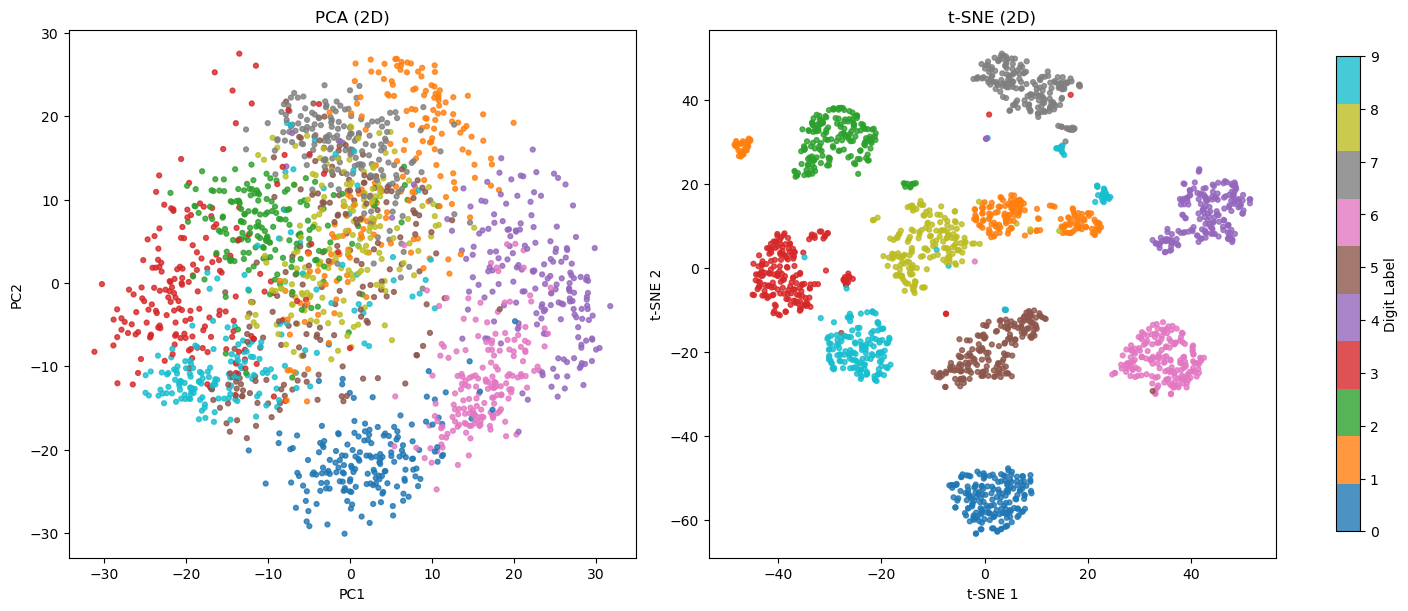

In [20]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# 复用前面已加载的数据
y = digits.target

# 左图：PCA 直接降到 2 维
pca_2 = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2.fit_transform(X)

# 右图：t-SNE 直接降到 2 维
tsne = TSNE(
    n_components=2,
    perplexity=30,
    early_exaggeration=12.0, # 早期夸大系数，可以调着玩，默认是12
    learning_rate="auto",
    init="pca",
    random_state=42,
    max_iter=1000
)
X_tsne_2d = tsne.fit_transform(X)

# 可视化：不同标签使用不同颜色
fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)

sc1 = axes[0].scatter(
    X_pca_2d[:, 0], X_pca_2d[:, 1],
    c=y, cmap="tab10", s=12, alpha=0.8
)
axes[0].set_title("PCA (2D)")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")

sc2 = axes[1].scatter(
    X_tsne_2d[:, 0], X_tsne_2d[:, 1],
    c=y, cmap="tab10", s=12, alpha=0.8
)
axes[1].set_title("t-SNE (2D)")
axes[1].set_xlabel("t-SNE 1")
axes[1].set_ylabel("t-SNE 2")

cbar = fig.colorbar(sc2, ax=axes, ticks=range(10), shrink=0.9)
cbar.set_label("Digit Label")

plt.show()

t-SNE的降维后结果已经自动分成了多个簇，且每个簇内的数字相对集中，虽然簇的数量略多于10，但每个簇内的数字类型相对单一，说明t-SNE成功地捕捉到了数据的局部结构和相似性。相比之下，PCA的结果虽然也显示了一定的分离，但不同数字之间的界限较为模糊。对于这种典型的高维数据，t-SNE能够更好地揭示数据的内在结构和分布特征。